In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


In [2]:
import pandas as pd

clinical = pd.read_csv("../data/clinical.csv")
radiology = pd.read_csv("../data/radiology.csv")


In [3]:
data = pd.concat(
    [
        clinical.drop(columns=["FVC", "MWT", "MWT_Class"]),
        radiology.drop(columns=["Warrick"])
    ],
    axis=1
)

data.head()


,Age,Sex,Smoking,DiseaseDuration,Comorbidities,Autoantibody,CTD_Type,Histology,FVC_Class,GGO_Volume,Fibrosis_Volume,Honeycombing,Pulm_HTN,Segments_Involved,Warrick_Class
0,60.960570,1,0,18.324801,2,ANA,PM/DM,OP,1,6.238570,8.341556,0,0,4,0
1,53.340828,1,0,20.000000,3,Anti-Jo1,SSc,UIP,2,7.142725,9.584800,0,0,9,0
2,62.772262,1,0,5.989319,0,Anti-RNP,RA,NSIP,1,12.530479,4.668266,0,0,5,0
3,73.276358,0,1,3.840392,1,Anti-RNP,PM/DM,NSIP,1,5.882057,14.124091,1,0,4,1
4,52.190160,0,1,1.851897,2,Anti-Jo1,PM/DM,NSIP,1,2.201801,10.601337,0,0,7,0


In [4]:
X = data.drop(columns=["FVC_Class"])
y = data["FVC_Class"]


In [5]:
from src.preprocessing import preprocess_data

X_train, X_test, y_train, y_test, preprocessor = preprocess_data(X, y)


In [6]:
from src.models import get_models
from src.evaluation import evaluate_models

models = get_models()
evaluate_models(models, X_train, X_test, y_train, y_test, preprocessor)


MODEL: NaiveBayes
              precision    recall  f1-score   support

           0       0.33      0.25      0.29         4
           1       0.90      0.93      0.92        30
           2       0.75      0.75      0.75         4

    accuracy                           0.84        38
   macro avg       0.66      0.64      0.65        38
weighted avg       0.83      0.84      0.83        38

AUROC (multiclass OvR): 0.824
Confusion Matrix:
[[ 1  2  1]
 [ 2 28  0]
 [ 0  1  3]]
MODEL: DecisionTree
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.82      0.93      0.88        30
           2       1.00      0.25      0.40         4

    accuracy                           0.76        38
   macro avg       0.61      0.39      0.42        38
weighted avg       0.76      0.76      0.73        38

AUROC (multiclass OvR): 0.615
Confusion Matrix:
[[ 0  4  0]
 [ 2 28  0]
 [ 1  2  1]]
MODEL: RandomForest
          

c:\Users\DEVANSH RAJPOOT\Upwork projects\ctd_ild_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DEVANSH RAJPOOT\Upwork projects\ctd_ild_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DEVANSH RAJPOOT\Upwork projects\ctd_ild_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

MODEL: GradientBoosting
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         4
           1       0.84      0.90      0.87        30
           2       0.50      0.25      0.33         4

    accuracy                           0.79        38
   macro avg       0.61      0.55      0.57        38
weighted avg       0.77      0.79      0.78        38

AUROC (multiclass OvR): 0.759
Confusion Matrix:
[[ 2  2  0]
 [ 2 27  1]
 [ 0  3  1]]
MODEL: KNN
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.78      0.97      0.87        30
           2       0.00      0.00      0.00         4

    accuracy                           0.76        38
   macro avg       0.26      0.32      0.29        38
weighted avg       0.62      0.76      0.68        38

AUROC (multiclass OvR): 0.705
Confusion Matrix:
[[ 0  4  0]
 [ 1 29  0]
 [ 0  4  0]]
MODEL: SVM
              precisio

c:\Users\DEVANSH RAJPOOT\Upwork projects\ctd_ild_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DEVANSH RAJPOOT\Upwork projects\ctd_ild_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DEVANSH RAJPOOT\Upwork projects\ctd_ild_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

In [7]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


In [8]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

preprocessor_lasso = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols)
])


In [9]:
lasso_model = LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=5000,
    C=0.5,
    random_state=42
)

lasso_pipeline = Pipeline([
    ("prep", preprocessor_lasso),
    ("lasso", lasso_model)
])

lasso_pipeline.fit(X, y)


c:\Users\DEVANSH RAJPOOT\Upwork projects\ctd_ild_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\DEVANSH RAJPOOT\Upwork projects\ctd_ild_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [10]:
feature_names = lasso_pipeline.named_steps["prep"].get_feature_names_out()
coefficients = lasso_pipeline.named_steps["lasso"].coef_

if coefficients.shape[0] == 1:
    coef_df = pd.DataFrame(
        coefficients.flatten(),
        index=feature_names,
        columns=["Severe_vs_nonSevere"]
    )
else:
    coef_df = pd.DataFrame(
        coefficients.T,
        index=feature_names,
        columns=["Mild_vs_rest", "Moderate_vs_rest", "Severe_vs_rest"]
    )

important_combined_features = coef_df[(coef_df != 0).any(axis=1)]
important_combined_features.sort_values(
    by=important_combined_features.columns[-1],
    key=abs,
    ascending=False
)


,Mild_vs_rest,Moderate_vs_rest,Severe_vs_rest
num__DiseaseDuration,-0.997988,0.000000,1.411660
num__Age,-0.981059,0.000000,0.470165
num__Smoking,0.000000,-0.021089,0.110855
num__Fibrosis_Volume,0.107948,0.000000,-0.056608
num__Honeycombing,0.000000,-0.005807,0.031632
cat__Histology_OP,0.000000,0.000000,-0.006970
num__GGO_Volume,0.000000,-0.120890,0.000000
num__Comorbidities,0.049249,-0.021722,0.000000
num__Sex,0.036471,-0.041486,0.000000
num__Pulm_HTN,0.274576,0.000000,0.000000


<Axes: title={'center': 'LASSO-selected Combined Clinical & Radiologic Predictors of Severe CTD-ILD'}>

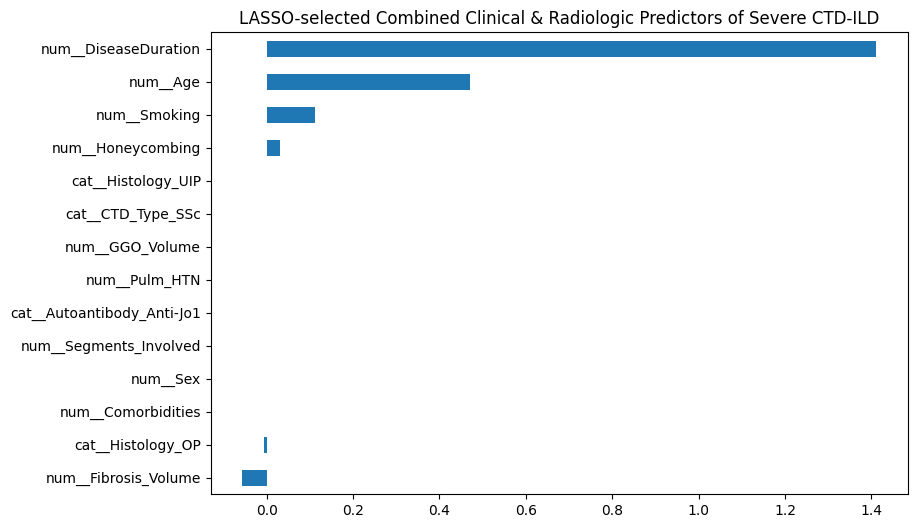

In [11]:
important_combined_features.iloc[:, -1].sort_values().plot(
    kind="barh",
    figsize=(9, 6),
    title="LASSO-selected Combined Clinical & Radiologic Predictors of Severe CTD-ILD"
)
